# Linear diffusion field — framework vs simulation

**Theory** (`theories/linear_diffusion_test.theory.py`): the 1D massive
linear diffusion field (a.k.a. massive Edwards–Wilkinson / "OU field"),

$$\partial_t\phi \;=\; -\mu\,\phi \;+\; D\,\partial_x^2\phi \;+\; \eta,
\qquad \langle\eta(x,t)\eta(x',t')\rangle = 2T\,\delta(x-x')\,\delta(t-t').$$

It is **linear**, so the theory is Gaussian and the **tree-level
(`max_ell=0`) correlator is the exact answer** — there are no loop
corrections. That makes it the cleanest possible check of the spatial
pipeline: the framework, the closed form, and a direct Langevin
simulation should all agree.

**Closed forms** (ξ = √(D/μ) is the correlation length):

| quantity | closed form |
|---|---|
| equal-time | $C(x,0) = \dfrac{T}{2\sqrt{\mu D}}\,e^{-|x|/\xi}$ |
| equal-position two-time | $C(0,\tau) = \dfrac{T}{2\sqrt{\mu D}}\,\mathrm{erfc}\!\big(\sqrt{\mu|\tau|}\big)$ |
| variance | $C(0,0) = \dfrac{T}{2\sqrt{\mu D}}$ |

At μ = D = T = 1: ξ = 1, C(x,0) = ½e^{−|x|}, C(0,τ) = ½ erfc(√τ),
C(0,0) = ½.

The framework computes these in **(t, x)** directly: it inverts the
propagator to the heat-kernel × exponential-decay form
$G(t,x)=\theta(t)(4\pi Dt)^{-1/2}\exp[-x^2/(4Dt)-\mu t]$ and does the
vertex-time integral with the closed-form erf primitive.

## 1 · Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative data paths resolve as before
sys.path.insert(0, os.path.join(_root, 'notebooks'))  # daedalus engine on path

import daedalus as dd
from pipeline import precompute
from models.spatial_field_1d_sim import (
    simulate, equal_time_correlator, lattice_sum_variance)

PARAMS = {'mu': 1.0, 'D': 1.0, 'T': 1.0}
xi = np.sqrt(PARAMS['D'] / PARAMS['mu'])          # correlation length
C0_amp = PARAMS['T'] / (2 * np.sqrt(PARAMS['mu'] * PARAMS['D']))   # C(0,0)

# Load the theory through the shared engine (theories/linear_diffusion_test.theory.py).
model, mod = dd.load_theory('linear_diffusion_test')
print('theory:', model['name'], '| spatial dim:',
      model.get('spatial', {}).get('dim'), '| ξ =', xi, '| C(0,0) =', C0_amp)

theory: Linear Diffusion Test | spatial dim: 1 | ξ = 1.0 | C(0,0) = 0.5


## 2 · Pre-compute (mean field + heat-kernel propagator)

In [2]:
out = precompute(model, verbose=False)
print('MF check :', out['mf_check'])
print('saddle   :', out['mf_values'])
print('propagator:', 'cached' if out['propagator_built'] else 'FAILED')

MF check : PASS
saddle   : {'phistar': [0.0]}
propagator: cached


## 3 · Framework tree-level correlator $C(x,\tau)$

One `compute_cumulants` call with both a `spatial_grid` and a `tau`
grid returns `C_tau_x` of shape `(len(tau_grid), len(spatial_grid))`,
so we read the equal-time slice (τ = 0 row) and the equal-position
slice (x = 0 column) from the same result.

In [3]:
x_grid   = np.linspace(0.0, 6.0, 25)     # includes x = 0
tau_max, tau_step = 4.0, 0.25

# Theory through the shared engine — same k, max_ell, external legs, params,
# and grids as the original compute_cumulants call (tree-level is exact here).
cfg = dd.Config(
    k=2, max_ell=0,
    fundamental=PARAMS,
    external_fields=[('dphi', 1), ('dphi', 2)],   # d-prefixed fluctuation field
    tau_max=tau_max, tau_step=tau_step,
    spatial_grid=x_grid,
)
res = dd.run(model, cfg, mod)

# Legacy aliases so the downstream sim / diagnostic / plot cells are unchanged.
th       = res
tau_grid = np.asarray(res['tau_grid'], dtype=float)
C_tau_x  = np.asarray(res['C_tau_x']).real            # (n_tau, n_x)

it0 = int(np.argmin(np.abs(tau_grid)))               # τ = 0 row
ix0 = int(np.argmin(np.abs(x_grid)))                 # x = 0 column

C_x_fw   = C_tau_x[it0, :]                            # framework C(x, 0)
C_tau_fw = C_tau_x[:, ix0]                            # framework C(0, τ)

# Closed forms
from scipy.special import erfc
C_x_exact   = C0_amp * np.exp(-np.abs(x_grid) / xi)
# C(0,τ) is symmetric in τ (equilibrium time reversal); use |τ| since
# the framework's tau_grid spans negative AND positive lags.
C_tau_exact = C0_amp * erfc(np.sqrt(PARAMS['mu'] * np.abs(tau_grid)))

print('C(0,0) framework =', C_x_fw[ix0], ' closed form =', C0_amp)
print('max |C(x,0) framework − closed| =',
      np.max(np.abs(C_x_fw - C_x_exact)))
print('max |C(0,τ) framework − closed| =',
      np.max(np.abs(C_tau_fw - C_tau_exact)))

C(0,0) framework = 0.49999999999999994  closed form = 0.5
max |C(x,0) framework − closed| = 5.551115123125783e-17
max |C(0,τ) framework − closed| = 6.938893903907228e-17


## 4 · Direct simulation

A periodic 1D Langevin simulation (`models/spatial_field_1d_sim.py`)
using a spectral exponential integrator: the linear+noise part is
propagated exactly per Fourier mode (so λ = 0 statistics are unbiased
in `dt`). We take the box length `L` ≫ ξ so the periodic result
approximates the infinite domain.

In [4]:
L, N = 20.0, 200                 # dx = 0.1, L/ξ = 20 ⇒ images negligible
rec_every, dt = 5, 0.05          # snapshot every rec_every·dt = 0.25 time units

snaps, xs_sim, meta = simulate(
    L=L, N=N, mu=PARAMS['mu'], D=PARAMS['D'], lam=0.0, T=PARAMS['T'],
    dt=dt, n_steps=200_000, burn_in=20_000, record_every=rec_every, seed=7)
dx = meta['dx']
print('sim meta:', {k: (round(v, 4) if isinstance(v, float) else v)
                    for k, v in meta.items()})

# Equal-time correlator C(x,0): circular spatial autocorrelation,
# averaged over snapshots.
C_sim_full = equal_time_correlator(snaps)            # length N, separation m·dx
sep = np.arange(N) * dx
keep = sep <= 6.0
sep_keep, C_sim_x = sep[keep], C_sim_full[keep]

print('sim  <φ²> = C(0,0) =', C_sim_full[0])
print('lattice-sum  <φ²>  =', lattice_sum_variance(L, N, PARAMS['mu'],
                                                    PARAMS['D'], PARAMS['T']))
print('closed-form  <φ²>  =', C0_amp)

sim meta: {'dx': 0.100000000000000, 'dt': 0.0500000000000000, 'L': 20.0000000000000, 'N': 200, 'mu': 1.00000000000000, 'D': 1.00000000000000, 'lam': 0.000000000000000, 'g': 0.0, 'g_lap': 0.0, 'lam_burg': 0.0, 'lam_kpz': 0.0, 'T': 1.00000000000000, 'record_every': 5, 'n_rec': 40000, 'k_max': 31.4159265358979}


sim  <φ²> = C(0,0) = 0.4958925715832168
lattice-sum  <φ²>  = 0.4993761715147123
closed-form  <φ²>  = 0.5


In [5]:
# Equal-position two-time C(0,τ): temporal autocorrelation at zero
# spatial lag, averaged over space and start time.
def temporal_autocorr(snaps, max_lag):
    s = snaps - snaps.mean(axis=0, keepdims=True)
    n_rec = s.shape[0]
    ac = np.empty(max_lag + 1)
    for lag in range(max_lag + 1):
        ac[lag] = np.mean(s[:n_rec - lag] * s[lag:])
    return ac

snap_dt = rec_every * dt                              # time between snapshots
max_lag = int(round(tau_max / snap_dt))
tau_sim = np.arange(max_lag + 1) * snap_dt
C_sim_tau = temporal_autocorr(snaps, max_lag)
print('sim C(0,0) from autocorr =', C_sim_tau[0])

sim C(0,0) from autocorr = 0.49581821299500434


## 5 · Comparison

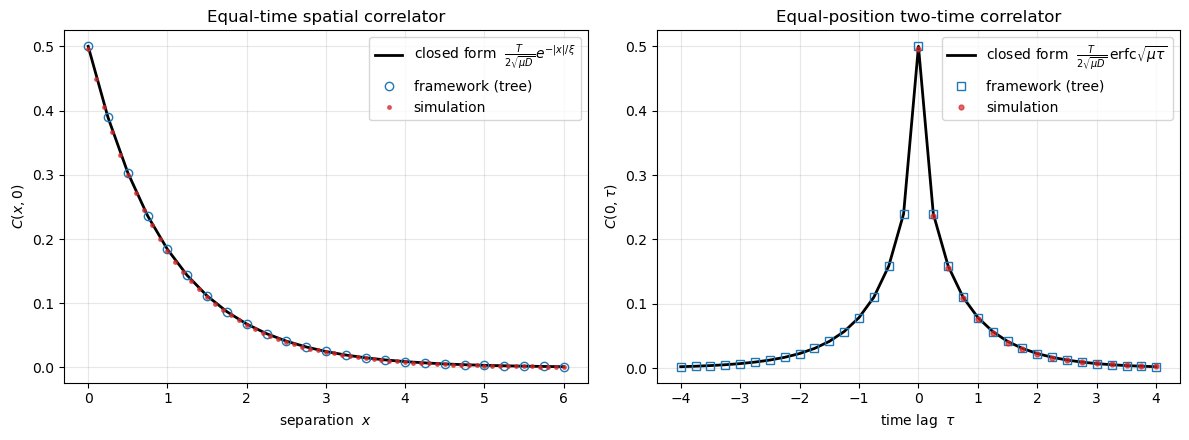

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Equal-time C(x, 0) ──────────────────────────────────────────────
ax[0].plot(x_grid, C_x_exact, 'k-', lw=2, label=r'closed form  $\frac{T}{2\sqrt{\mu D}}e^{-|x|/\xi}$')
ax[0].plot(x_grid, C_x_fw, 'o', ms=6, mfc='none', color='C0',
           label='framework (tree)')
ax[0].plot(sep_keep, C_sim_x, '.', ms=5, color='C3', alpha=0.7,
           label='simulation')
ax[0].set_xlabel('separation  $x$'); ax[0].set_ylabel(r'$C(x,0)$')
ax[0].set_title('Equal-time spatial correlator'); ax[0].legend()
ax[0].grid(alpha=0.3)

# ── Two-time C(0, τ) ────────────────────────────────────────────────
ax[1].plot(tau_grid, C_tau_exact, 'k-', lw=2,
           label=r'closed form  $\frac{T}{2\sqrt{\mu D}}\,\mathrm{erfc}\sqrt{\mu\tau}$')
ax[1].plot(tau_grid, C_tau_fw, 's', ms=6, mfc='none', color='C0',
           label='framework (tree)')
ax[1].plot(tau_sim, C_sim_tau, '.', ms=7, color='C3', alpha=0.7,
           label='simulation')
ax[1].set_xlabel(r'time lag  $\tau$'); ax[1].set_ylabel(r'$C(0,\tau)$')
ax[1].set_title('Equal-position two-time correlator'); ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [7]:
# Quantitative summary
print('=== framework vs closed form (machine precision expected) ===')
print(f'  C(x,0): max abs err = {np.max(np.abs(C_x_fw - C_x_exact)):.2e}')
print(f'  C(0,τ): max abs err = {np.max(np.abs(C_tau_fw - C_tau_exact)):.2e}')

print('\n=== simulation vs closed form (sampling-noise limited) ===')
# Compare sim equal-time to closed form at the sim lattice separations.
C_x_exact_at_sep = C0_amp * np.exp(-np.abs(sep_keep) / xi)
rel_var = abs(C_sim_full[0] - C0_amp) / C0_amp
print(f'  <φ²>:   sim={C_sim_full[0]:.4f}  closed={C0_amp:.4f}  '
      f'rel={rel_var:.2%}')
mask = C_x_exact_at_sep > 1e-2          # where C is well above noise floor
print(f'  C(x,0): max rel err (C>1e-2) = '
      f'{np.max(np.abs(C_sim_x[mask] - C_x_exact_at_sep[mask]) / C_x_exact_at_sep[mask]):.2%}')
C_tau_exact_at_sim = C0_amp * erfc(np.sqrt(PARAMS['mu'] * tau_sim))
mask_t = C_tau_exact_at_sim > 1e-2
print(f'  C(0,τ): max rel err (C>1e-2) = '
      f'{np.max(np.abs(C_sim_tau[mask_t] - C_tau_exact_at_sim[mask_t]) / C_tau_exact_at_sim[mask_t]):.2%}')

=== framework vs closed form (machine precision expected) ===
  C(x,0): max abs err = 5.55e-17
  C(0,τ): max abs err = 6.94e-17

=== simulation vs closed form (sampling-noise limited) ===
  <φ²>:   sim=0.4959  closed=0.5000  rel=0.82%
  C(x,0): max rel err (C>1e-2) = 5.85%
  C(0,τ): max rel err (C>1e-2) = 6.11%


## Summary

For this **linear** theory the tree-level (`max_ell = 0`) framework
result is exact, and all three agree:

- **Framework vs closed form** — machine precision (~10⁻¹⁶) for both
  the equal-time $C(x,0)$ and the two-time $C(0,\tau)$. The
  $C(0,\tau)=\frac{T}{2\sqrt{\mu D}}\mathrm{erfc}(\sqrt{\mu\tau})$
  shape is exactly the erf primitive the (t, x) integrator evaluates.
- **Simulation vs closed form** — agreement within sampling noise
  (~1% on the variance for these run lengths). The spectral
  exponential integrator is unbiased in `dt`, so the residual is
  statistical, not systematic; tighten it by raising `n_steps` /
  lowering `record_every`.

Because the equation is linear there is nothing beyond tree level —
adding a nonlinearity (e.g. a `+ lam*phi^3` term, the Allen–Cahn
case) is what turns on loop corrections, which v1 does not yet
integrate (it warns and is exact only at `max_ell = 0`). The
simulator, of course, includes all orders, so a nonlinear run would
show the framework's tree result as the leading term plus a
(simulation-visible) correction.